# ANALIZA PODATKOV O FILMIH

Preučila bom različne podatke za izbranih 30 filmov, ki so se pojavljali na lestvici *Daily Box Office for 2026*. Analizirala bom njihov dnevni in povprečni dnevni zaslužek, trajanje, distributerja, žanre ter število dni, ko so bili na prvem mestu.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
filmi = pd.read_csv('podatki/seznam_filmov_dopolnjeno.csv')
filmi.head()

,naslov,distributer,trajanje,žanri,datum izzida,št. dni na 1. mestu,največji dnevni zaslužek
0,Spider-Man: Brand New Day,Sony Pictures Releasing,2 hr 25 min,"akcijski, pustolovski, znanstvenofantastični","Jul 31, 2026",23,169843039
1,Insidious: Out of the Further,Sony Pictures Releasing,1 hr 46 min,"grozljivka, skrivnostni, triler","Aug 21, 2026",1,10675888
2,The Odyssey,Universal Pictures,2 hr 52 min,"akcijski, pustolovski, fantazijski","Jul 17, 2026",14,50977435
3,Moana,Walt Disney Studios Motion Pictures,1 hr 55 min,"akcijski, pustolovski, komedija, družinski, fa...","Jul 10, 2026",7,18510043
4,Minions & Monsters,Universal Pictures,1 hr 30 min,"pustolovski, animirani, komedija, družinski","Jul 1, 2026",9,16506115


In [22]:
filmi.shape

(30, 7)

*1. Ali obstaja povezava med največjim dnevnim zaslužkom filma in številom dni, ko je bil film na prvem mestu lestivice?*

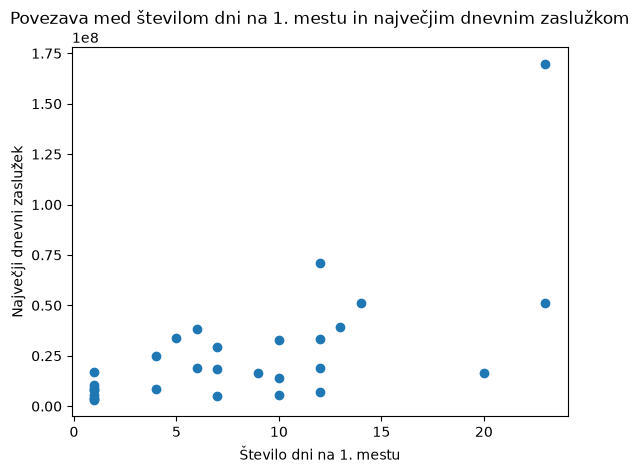

In [23]:
plt.scatter(
    filmi["št. dni na 1. mestu"],
    filmi["največji dnevni zaslužek"]
)

plt.xlabel("Število dni na 1. mestu")
plt.ylabel("Največji dnevni zaslužek")
plt.title(
    "Povezava med številom dni na 1. mestu "
    "in največjim dnevnim zaslužkom"
)

plt.show()

Med številom dni na prvem mestu lestivice in največjim dnevnim zaslužkom je opazna pozitivna povezava. Vendar povezava ni popolna, saj se pri filmih z enakim ali podobnim številom dni na prvem mestu največji dnevni zaslužek lahko precej razlikuje. Ocenim lahko, da za večino filmov večji zaslužek pomeni višje število dni na prvem mestu. Filmi, ki so se na prvo mesto uvrstili samo za en dan, imajo praviloma nižji največji dnevni zaslužek kot filmi, ki so bili na lestvici več kot en dan. 
Na grafu posebej izstopata filma na skrajno desni strani, ki sta bila največ dni na prvem mestu, vendar se njuna največja dnevna zaslužka precej razlikujeta. Sklepam lahko torej, da število dni na prvem mestu ne določa višine največjega dnevnega zaslužka. Na uspešnost filma vplivajo tudi drugi dejanviki, nekatere od teh bom raziskala v nadaljevanju naloge.

*2.1 Kateri žanri se najpogosteje pojavljajo med izbranimi filmi?*

In [24]:
zanri = filmi["žanri"].str.split(",").explode().str.strip()

tabela_zanrov = (zanri.value_counts().reset_index())

tabela_zanrov.columns = ["Žanr", "Število filmov"]

tabela_zanrov

,Žanr,Število filmov
0,pustolovski,15
1,znanstvenofantastični,12
2,komedija,12
3,drama,10
4,akcijski,9
5,grozljivka,9
6,triler,9
7,družinski,8
8,fantazijski,7
9,animirani,7


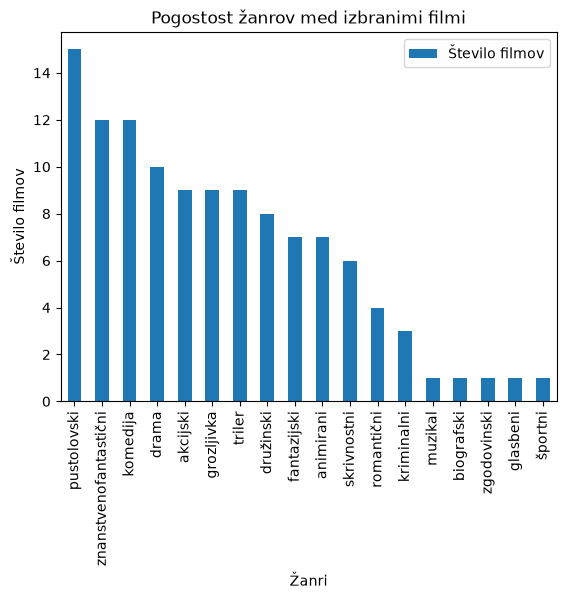

In [25]:
tabela_zanrov.plot(x="Žanr", y="Število filmov", kind="bar")
plt.xlabel("Žanri")
plt.ylabel("Število filmov")
plt.title("Pogostost žanrov med izbranimi filmi")
plt.show()

Za prikaz pogostosti posameznih žanrov sem uporabila stolpični diagram, ker omogoča pregledno primerjavo števila pojavitev med velikim številom kategorij.
Med izbranimi filmi je najpogosteje zastopan pustolovski žanr, ki se pojavi pri 15 filmih. Sledita znanstvenofantastični žanr in komedija z 12 pojavitvami, nato drama z desetimi. Žanri kot so muzikal, biografski, zgodovinski, glasbeni in športni, se pojavijo le enkrat. To kaže na neenakomerno zastopanost žanrov v izbranem vzorcu. Med pogostejšimi so tudi akcijski, pustolovski in znanstvenofantastični žanr, ki se lahko pri posameznem filmu med seboj prepletajo, saj imajo nekateri filmi več navedenih žanrov. Pudariti moram, da rezultati opisujejo predvsem značilnosti izbranih 30 filmov in jih ne moremo neposredno posplošiti na vse filme. Ker imajo nekateri filmi več žanrov se ponuja naslednje vprašanje.

*2.2 Kako pogosto se pojavljajo kombinacije žanrov pri izbranem naboru filmov in kateri pari žanrov se najpogosteje pojavljajo skupaj?*

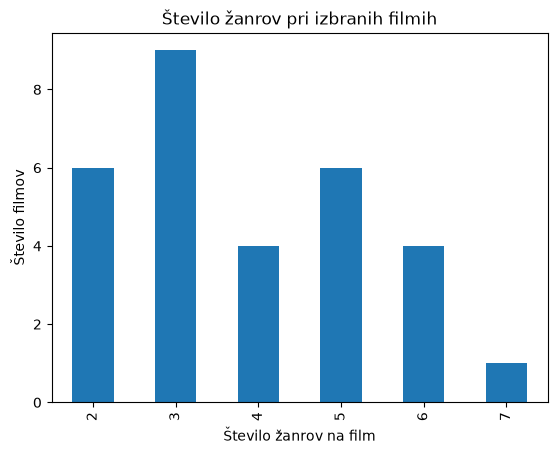

In [26]:
stevilo_zanrov_na_film = filmi["žanri"].str.split(",").str.len()
stevilo_zanrov_na_film.value_counts().sort_index().plot(kind="bar")

plt.xlabel("Število žanrov na film")
plt.ylabel("Število filmov")
plt.title("Število žanrov pri izbranih filmih")

plt.show()

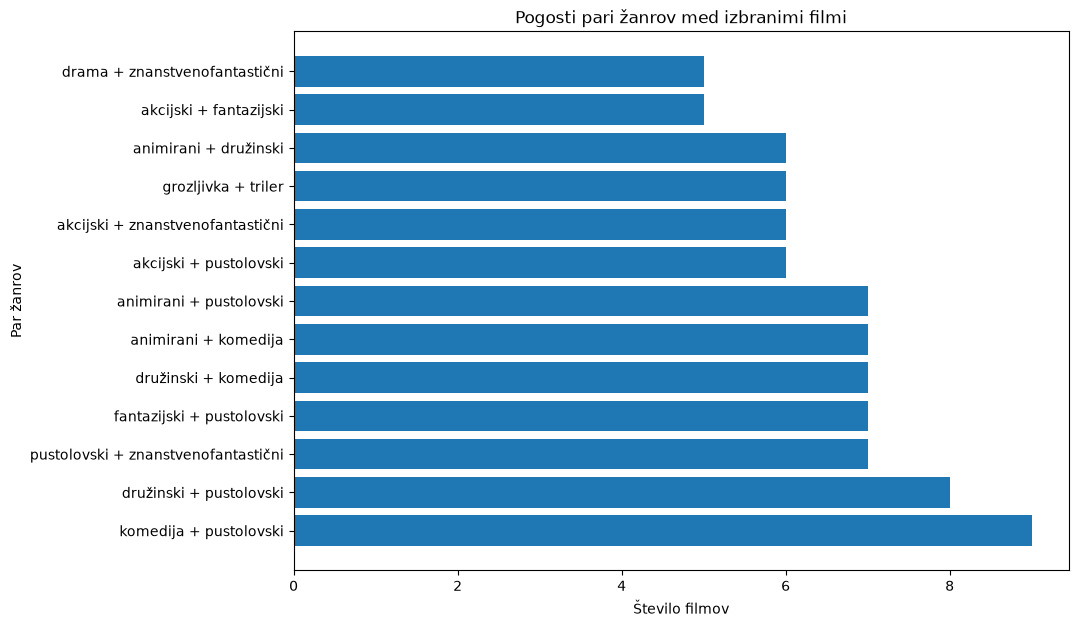

In [27]:
from itertools import combinations
from collections import Counter

pari_zanrov = []

for zanri_filma in filmi["žanri"]:
    seznam_zanrov = [z.strip() for z in zanri_filma.split(",")]
    pari = list(combinations(sorted(seznam_zanrov), 2))
    pari_zanrov.extend(pari)

stevilo_parov = Counter(pari_zanrov)

pogosti_pari = [(par, stevilo) for par, stevilo in stevilo_parov.items() if stevilo >= 5]

pogosti_pari = sorted(pogosti_pari, key=lambda x: x[1], reverse=True)

oznake = [f"{a} + {b}" for (a, b), stevilo in pogosti_pari]
vrednosti = [stevilo for (a, b), stevilo in pogosti_pari]

plt.figure(figsize=(10, 7))
plt.barh(oznake, vrednosti)
plt.xlabel("Število filmov")
plt.ylabel("Par žanrov")
plt.title("Pogosti pari žanrov med izbranimi filmi")

plt.show()

Kaže, da izbrani filmi niso omejeni na en sam žanr, temveč imajo več kombinacij. Največ filmov, 9, jih ima tri žanre, po 6 filmov pa jih ima dva oziroma pet žanrov. Štirje filmi imajo štiri žanre, štirje šest žanrov, en film pa ima kar sedem različnih žanrskih oznak.
Pri analizi posameznih parov žanrov sem ugotovila, da se najpogosteje skupaj pojavljata komedija in pustolovski žanr, ki se pojavita pri 9 filmih. Sledita kombinaciji družinskega ter pustolovskega žanra z 8 pojavitvami. Več parov ima po 7 pojavitev, med drugim pustolovski in znanstvenofantastični, fantazijski in pustolovski ter družinski in komedija.
Pri tem izstopa predvsem pustolovski žanr, kar sem že potrdila z vprašanjem številka 2.1, ter je zelo pogosto prisoten v različnih komcinacijah žanrov, kot so komedija, družinski, znanstvenofantastični, fantazijski ali akcijski žanr. Skepam, da so filmi pogosto opisani z različnimi žanrskimi značilnostmi.


*3. Ali se trajanje filma razlikuje glede na pet najpogostejših kombinacij žanrov?*

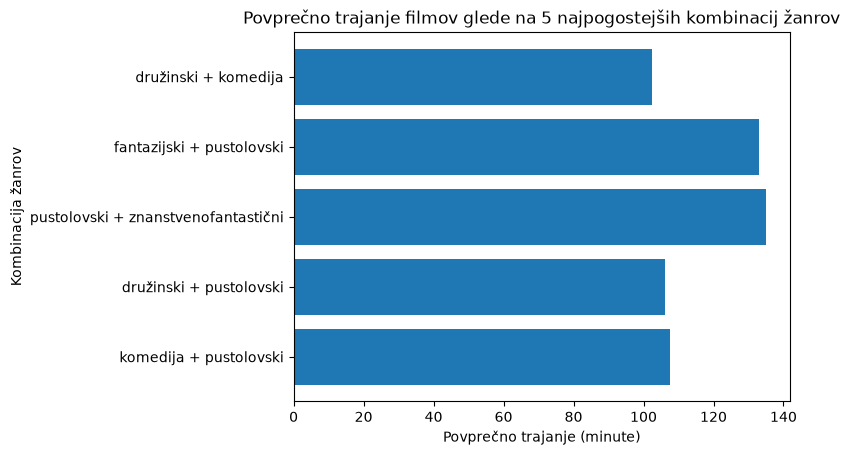

In [28]:
trajanje_v_min = []

for cas in filmi["trajanje"]:
    deli = cas.split()
    ure = int(deli[0])
    minute = int(deli[2])
    trajanje_v_min.append(ure * 60 + minute)

filmi["trajanje_min"] = trajanje_v_min

povprecno_trajanje_parov = []

for (a, b), stevilo in pogosti_pari[:5]:
    trajanja = []

    for i, zanri in enumerate(filmi["žanri"]):
        if a in zanri and b in zanri:
            trajanja.append(filmi["trajanje_min"].iloc[i])

    povprecno_trajanje_parov.append(sum(trajanja) / len(trajanja))

oznake = [f"{a} + {b}" for (a, b), stevilo in pogosti_pari[:5]]
plt.barh(oznake, povprecno_trajanje_parov)

plt.xlabel("Povprečno trajanje (minute)")
plt.ylabel("Kombinacija žanrov")
plt.title("Povprečno trajanje filmov glede na 5 najpogostejših kombinacij žanrov")

plt.show()

Primerjala sem povprečno trajanje filmov glede na pet najpogostejših kombinacij žanrov, ki sem jih raziskala v točki 2.2. Rezultati kažejo, da se povprečno trajanje med posameznimi kombinacijami razlikuje. Izstopata kombinaciji fantazijski + pustolovski in pustolovski + znanstvenofantastični, pri katerih je povprečno trajanje približno 25-35 min daljše kot pri ostalih priljubljenih kombinacijah filmov.
Pri interpretaciji rezultatov je treba upoštevati, da ima posamezen film lahko več žanrov, zato se lahko isti film pojavi pri več analiziranih kombinacijah. Na primer, če ima film kombinacijo žanrov, ki se pojavi med petimi najpogostejšimi kombinacijami, lahko njegovo trajanje prispeva k povprečju več različnih kombinacij. Skupine zato niso popolnoma ločene in rezultatov ne smemo razumeti tako, da vsak film pripada samo eni kombinaciji.
Na podlagi grafa lahko zaključim, da so med izbranimi petimi kombinacijami najdaljši filmi povezani predvsem s kombinacijama fantazijskega in pustolovskega žanra ter pustolovskega in znanstvenofantastičnega žanra.

*4. Kateri distributerji prevladujejo med izbranimi filmi in ali se njihova zastopanost odraža tudi v povprečnem dnevnem zaslužku njihovih filmov?*

In [29]:
stevilo_distributerjev = filmi["distributer"].value_counts()
tabela_distributerjev = stevilo_distributerjev.reset_index()
tabela_distributerjev.columns = ["Distributer", "Število filmov"]
tabela_distributerjev

,Distributer,Število filmov
0,Walt Disney Studios Motion Pictures,7
1,Universal Pictures,5
2,Sony Pictures Releasing,4
3,Paramount Pictures,2
4,Warner Bros.,2
5,Amazon MGM Studios,2
6,Focus Features,1
7,Fathom Entertainment,1
8,A24,1
9,Lionsgate,1


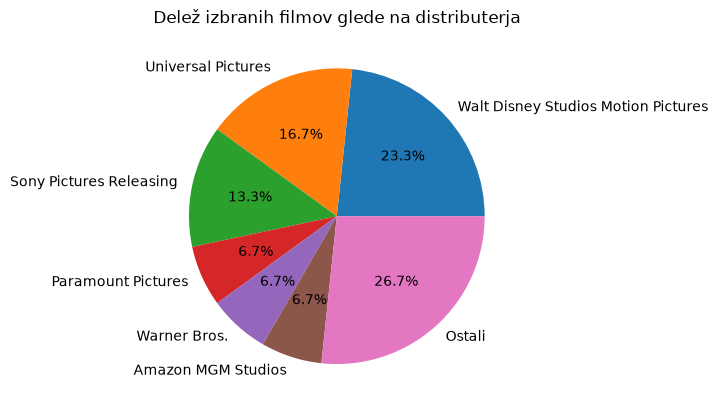

In [30]:
stevilo_distributerjev = filmi["distributer"].value_counts()

glavni = stevilo_distributerjev[stevilo_distributerjev >= 2]

ostali = stevilo_distributerjev[stevilo_distributerjev == 1].sum()

podatki_graf = pd.concat([glavni, pd.Series({"Ostali": ostali})])

podatki_graf.plot(kind="pie", autopct="%1.1f%%")

plt.title("Delež izbranih filmov glede na distributerja")

plt.show()

In [31]:
dnevni_podatki = pd.read_csv("podatki/dnevni_podatki.csv")
povprecni_zasluzek = dnevni_podatki.groupby("naslov")["dnevni zaslužek"].mean()
filmi["povprecni_dnevni_zasluzek"] = filmi["naslov"].map(povprecni_zasluzek)

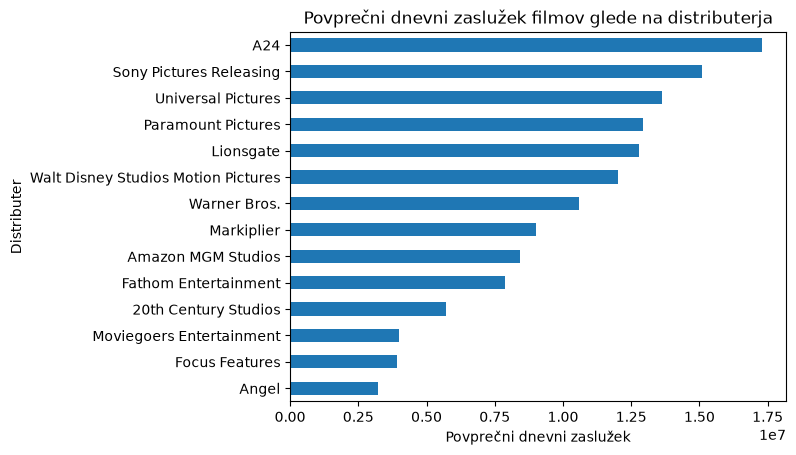

In [32]:
povprecje_distributerjev = filmi.groupby("distributer")["povprecni_dnevni_zasluzek"].mean()
povprecje_distributerjev = povprecje_distributerjev.sort_values()

povprecje_distributerjev.plot(kind="barh")

plt.xlabel("Povprečni dnevni zaslužek")
plt.ylabel("Distributer")
plt.title("Povprečni dnevni zaslužek filmov glede na distributerja")

plt.show()

Najbolj zastopani distributerji so Walt Disney Studios Motion Pictures, ki ima 7 filmov, sledita Universal Pictures s 5 filmi in Sony Pictures Releasing s 4 filmi, ki si delijo več kot polovico najuspešnejših filmov glede na zastopanost na 1. mestu lestvice. Ostali distributerji imajo slabšo zastopanost z enim al dvema filmoma.
Zdi se, da bi bili ti trije distributerji tudi najuspešnjši glede na največji povprečni dnevni zaslužek, vendar nadaljna analiza temu močno nasprotuje. Najvišji povprečni dnevni zaslužek ima A24, čeprav ima med izbranimi filmi samo enega. Sledijo Sony Pictures Releasing, Universal Pictures in Paramount Pictures. Walt Disney Studios Motion Pictures, ki je najbolj zastopan distributer, se po povprečnem dnevnem zaslužku uvršča šele na šesto mesto.
Rezultati kažejo, da večja zastopanost distributerja med izbranimi filmi ne pomeni nujno tudi višjega povprečnega dnevnega zaslužka njegovih filmov. Vendar na podlagi teh podatkov ne morem določiti, kateri distributer je na splošno najuspešnejši. Analiza temelji le na izbranih filmih in dnevnih podatkih, ki jih imamo za dneve, ko so bili filmi vključeni v obravnavano lestvico. Zato lahko zaključim le, kateri distributerji so bili v vzorcu najbolj zastopani in kateri so imeli v tem vzorcu najvišji povprečni dnevni zaslužek. Celotna slika bi se lahko precej spremenila, če bi računala s podatki, ko filmi niso bili uvrščni na lestvico, kljub temu pa so ustvarjali dnevni zaslužek.

*5.1 Kako se povprečni dnevni zaslužek spreminja skozi čas?*

*5.2 Ali so skoki na grafu povezani z datumi izidov filmov?*

In [33]:
filmi = pd.read_csv("podatki/seznam_filmov_dopolnjeno.csv")
filmi["datum izzida"] = pd.to_datetime(filmi["datum izzida"])

datumi_izidov = filmi[["naslov", "datum izzida"]]
print(datumi_izidov.shape)

(30, 2)


*OPOMBA: Zgornja tabela je velikosti 30 × 2, vendar bom za označevanje na spodnjem grafu uporabila le 28 filmov, saj obravnavam podatke za leto 2026. Dva filma iz našega nabora sta bila namreč izdana že leta 2025.*

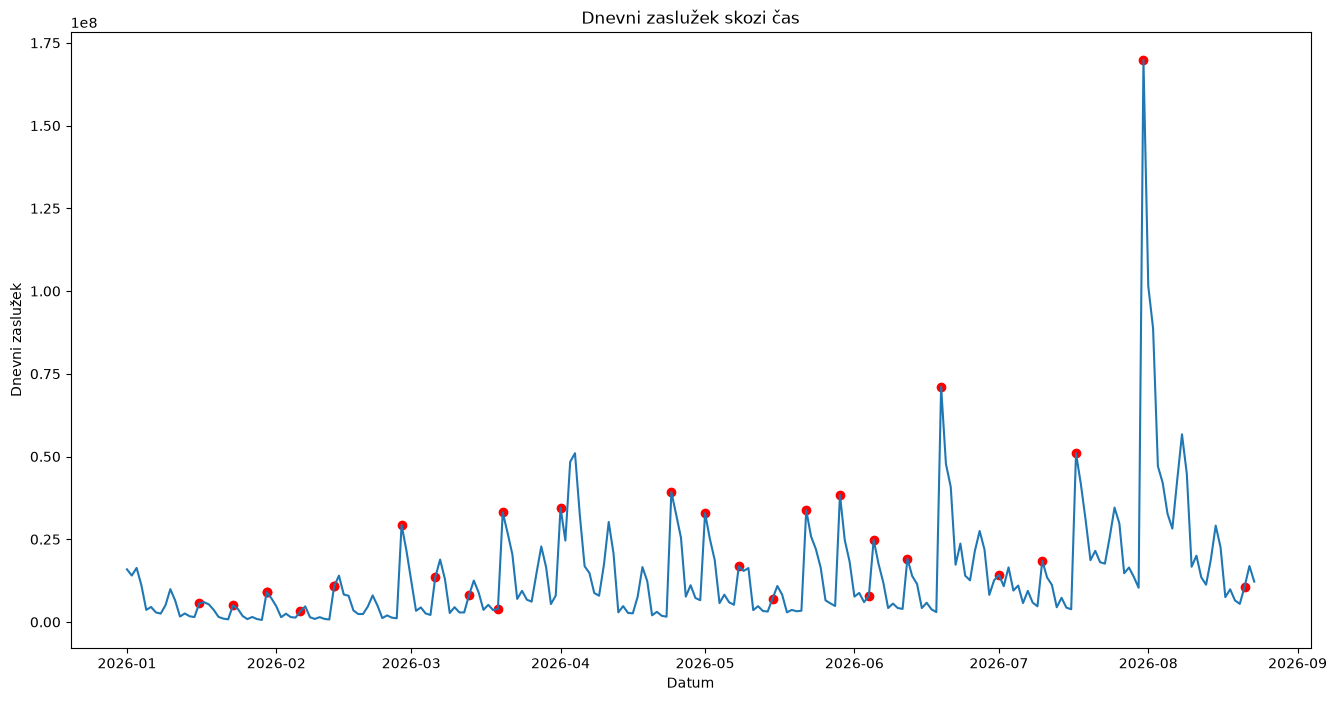

In [34]:
dnevni_podatki = pd.read_csv("podatki/dnevni_podatki.csv")

dnevni_podatki["datum"] = pd.to_datetime(dnevni_podatki["datum"] + " 2026")

datumi_izidov = datumi_izidov[datumi_izidov["datum izzida"].dt.year == 2026]

vrednosti_na_dan_izida = dnevni_podatki.set_index(
    "datum"
).loc[
    datumi_izidov["datum izzida"],
    "dnevni zaslužek"
]

plt.figure(figsize=(16, 8))

plt.plot(dnevni_podatki["datum"], dnevni_podatki["dnevni zaslužek"])

plt.scatter(
    datumi_izidov["datum izzida"],
    vrednosti_na_dan_izida,
    color="red"
)

plt.xlabel("Datum")
plt.ylabel("Dnevni zaslužek")
plt.title("Dnevni zaslužek skozi čas")

plt.show()

Povprečni dnevni zaslužek se skozi leto spreminja in niha. Največji porasti so skoncentrirani predvsem v obdobjih večjih filmskih izidov, medtem ko so med posameznimi izidi vidna tudi obdobja nižjega zaslužka.
Sklepam, da so izidi filmov povezani s povečanjem povprečnega dnevnega zaslužka, vendar povezava ni vedno prisotna. Na zaslužek tako vplivajo tudi drugi dejavniki, ki jih v projektni nalogi ne bom obravnavala.

Najizrazitejši skok v povprečnem dnevnem zaslužku se pojavi 31. julija 2026, ko je izšel film Spider-Man: Brand New Day. To je tudi najvišji zabeleženi skok v obravnavanem obdobju in predstavlja najbolj očiten primer povezave med filmskim izidom in povečanjem zaslužka.

*6. Kako se razlikujeta dnevna zaslužka filmov, ki sta bila največ dni na prvem mestu?*

In [35]:
filmi = pd.read_csv("podatki/seznam_filmov_dopolnjeno.csv")

najvec_dni = filmi["št. dni na 1. mestu"].max()

filmi_najvec_dni = filmi[filmi["št. dni na 1. mestu"] == najvec_dni]

print(filmi_najvec_dni[["naslov", "št. dni na 1. mestu"]])

                          naslov  št. dni na 1. mestu
0      Spider-Man: Brand New Day                   23
15  The Super Mario Galaxy Movie                   23


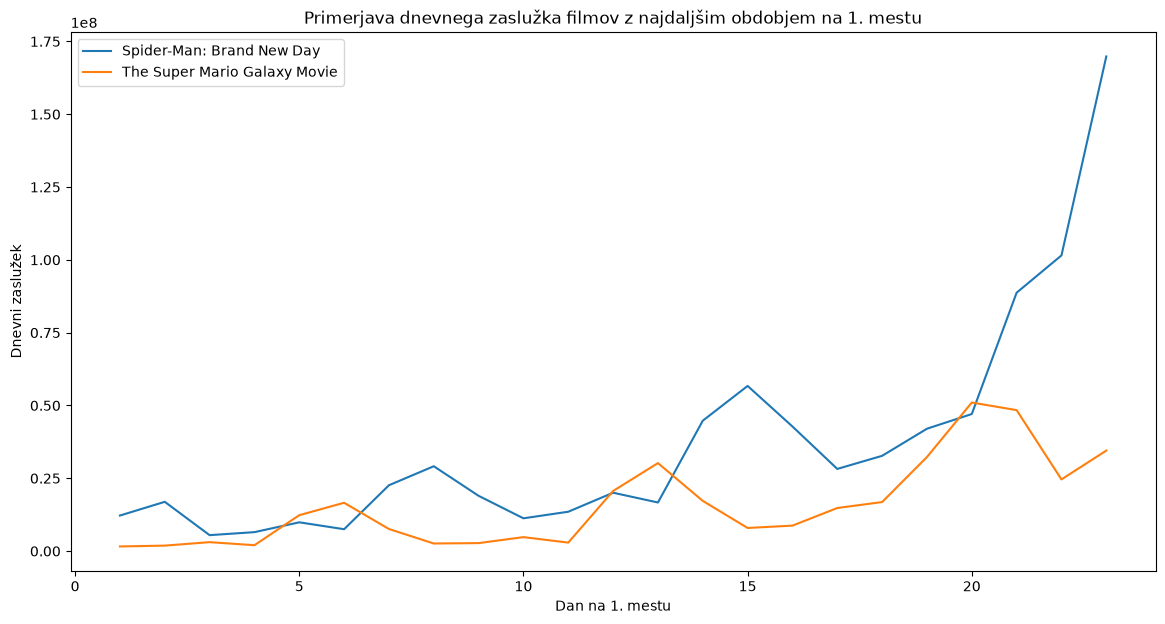

In [36]:
dnevni_podatki = pd.read_csv("podatki/dnevni_podatki.csv")

film_1 = dnevni_podatki[dnevni_podatki["naslov"] == 'Spider-Man: Brand New Day'].copy()
film_2 = dnevni_podatki[dnevni_podatki["naslov"] == 'The Super Mario Galaxy Movie'].copy()

film_1['dan'] = range(1, len(film_1) + 1)
film_2['dan'] = range(1, len(film_2) + 1)

plt.figure(figsize=(14, 7))
plt.plot(film_1['dan'], film_1['dnevni zaslužek'], label = 'Spider-Man: Brand New Day')
plt.plot(film_2['dan'], film_2['dnevni zaslužek'], label = 'The Super Mario Galaxy Movie')


plt.xlabel('Dan na 1. mestu')
plt.ylabel('Dnevni zaslužek')
plt.title('Primerjava dnevnega zaslužka filmov z najdaljšim obdobjem na 1. mestu')
plt.legend()
plt.show()


In [37]:
skupni_1 = film_1['dnevni zaslužek'].sum()
skupni_2 = film_2['dnevni zaslužek'].sum()

povprecni_1 = film_1['dnevni zaslužek'].mean()
povprecni_2 = film_2['dnevni zaslužek'].mean()

razlika_skupni = skupni_1 - skupni_2
razlika_povprecni = povprecni_1 - povprecni_2

print("Razlika v skupnem zaslužku:", razlika_skupni)

odstotna_povprecni = (razlika_povprecni / povprecni_2) * 100
print("Odstotna razlika v povprečnem zaslužku:", odstotna_povprecni, "%")

tabela_zasluzek = pd.DataFrame({
    "Film": ["Spider-Man: Brand New Day", "The Super Mario Galaxy Movie"],
    "Skupni zaslužek": [skupni_1, skupni_2],
    "Povprečni dnevni zaslužek": [povprecni_1, povprecni_2]
})

tabela_zasluzek["Povprečni dnevni zaslužek"] = tabela_zasluzek["Povprečni dnevni zaslužek"].round(0).astype(int)
tabela_zasluzek


Razlika v skupnem zaslužku: 479727524
Odstotna razlika v povprečnem zaslužku: 131.3267232084697 %


,Film,Skupni zaslužek,Povprečni dnevni zaslužek
0,Spider-Man: Brand New Day,845020674,36740029
1,The Super Mario Galaxy Movie,365293150,15882311


Primerjava kaže, da je bil Spider-Man: Brand New Day v obdobju 23 dni, ko sta bila oba filma na 1. mestu, glede na dnevni zaslužek uspešnejši od The Super Mario Galaxy Movie. Spider-Man je v tem obdobju dosegel 845.020.674$ skupnega zaslužka, medtem ko je The Super Mario Galaxy Movie dosegel 365.293.150$, kar predstavlja razliko 479.727.524$. Tudi povprečni dnevni zaslužek je bil pri Spider-Manu višji za približno 131,33 %.
Pri obeh filmih lahko spremljamo tudi spreminjanje zaslužka skozi zaporedne dni. Zanimivo je opaziti, da se krivulji obeh filmov vzpenjata čez čas, kar kaže na rast dnevnega zaslužka v opazovanem obdobju.
Opozoriti moram, da primerjava temelji le na dnevih, ko sta bila filma med najuspešnejšimi oz. na 1. mestu, zato rezultat ne predstavlja njunega celotnega zaslužka skozi celotno predvajanje.